In [ ]:
pip install pandas scikit-learn matplotlib seaborn

In [ ]:



import pandas as pd
# Load the dataset
data = pd.read_csv('/content/Afficionado Coffee Roasters.xlsx - Transactions.csv')
data.head(5)

,transaction_id,year,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2025,7:06:11,2,5,Lower Manhattan,32,3,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2025,7:08:56,2,5,Lower Manhattan,57,"3,1",Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2025,7:14:04,2,5,Lower Manhattan,59,"4,5",Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2025,7:20:24,1,5,Lower Manhattan,22,2,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2025,7:22:41,2,5,Lower Manhattan,57,"3,1",Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [ ]:

#Data ingestion and validation

#file_path = "Transactions.csv"
#data = pd.read_csv('/content/Afficionado Coffee Roasters.xlsx – Transactions.csv')

In [ ]:




data['transaction_time'] = pd.to_datetime(data['transaction_time'], format='%H:%M:%S', errors='coerce')
print(data.head())

data = data.sort_values(by='transaction_time').reset_index(drop=True)

print("Initial Shape:", data.shape)
print("Columns:", data.columns.tolist())

duplicate_rows = data[data.duplicated()]
print(f"Number of duplicate rows: {duplicate_rows.shape[0]}")
if not duplicate_rows.empty:
  print(duplicate_rows.head())
else:
  print("No duplicate rows found.")


print(f"Data type of 'product_id': {data['product_id'].dtype}")
print(f"Missing values in 'product_id': {data['product_id'].isnull().sum()}")

non_positive_product_ids = data[data['product_id'] <= 0]
if not non_positive_product_ids.empty:
  print("Non-positive 'product_id' values found:")
  print(non_positive_product_ids)
else:
  print("All 'product_id' values are positive.")

print(f"Original data type of 'unit_price': {data['unit_price'].dtype}")
print(f"Missing values in 'unit_price' before conversion: {data['unit_price'].isnull().sum()}")

   transaction_id  year    transaction_time  transaction_qty  store_id  \
0               1  2025 1900-01-01 07:06:11                2         5   
1               2  2025 1900-01-01 07:08:56                2         5   
2               3  2025 1900-01-01 07:14:04                2         5   
3               4  2025 1900-01-01 07:20:24                1         5   
4               5  2025 1900-01-01 07:22:41                2         5   

    store_location  product_id unit_price    product_category  \
0  Lower Manhattan          32          3              Coffee   
1  Lower Manhattan          57        3,1                 Tea   
2  Lower Manhattan          59        4,5  Drinking Chocolate   
3  Lower Manhattan          22          2              Coffee   
4  Lower Manhattan          57        3,1                 Tea   

            product_type               product_detail  
0  Gourmet brewed coffee                  Ethiopia Rg  
1        Brewed Chai tea     Spicy Eye Opener Chai L

In [ ]:


# Convert 'unit_price' to numeric, replacing commas with periods and coercing errors
data['unit_price'] = data['unit_price'].astype(str).str.replace(',', '.', regex=False)
data['unit_price'] = pd.to_numeric(data['unit_price'], errors='coerce')

print(f"\nData type of 'unit_price' after conversion: {data['unit_price'].dtype}")
print(f"NaN values in 'unit_price' after conversion (introduced due to errors): {data['unit_price'].isnull().sum()}")

if data['unit_price'].isnull().sum() > 0:
  median_unit_price = data['unit_price'].median()
  data['unit_price'].fillna(median_unit_price, inplace=True)
  print(f"Filled NaN values in 'unit_price' with median: {median_unit_price}")
else:
  print("No NaN values to fill in 'unit_price'.")

non_positive_unit_prices = data[data['unit_price'] <= 0]
if not non_positive_unit_prices.empty:
  print("Non-positive 'unit_price' values found:")
  print(non_positive_unit_prices)
else:
  print("All 'unit_price' values are positive.")


print(f"Data type of 'transaction_qty': {data['transaction_qty'].dtype}")
print(f"Missing values in 'transaction_qty': {data['transaction_qty'].isnull().sum()}")

non_positive_transaction_qty = data[data['transaction_qty'] <= 0]
if not non_positive_transaction_qty.empty:
	print("\nNon-positive 'transaction_qty' values found:")
	print(non_positive_transaction_qty)
else:
	print("\nAll 'transaction_qty' values are positive.")

min_qty = data['transaction_qty'].min()
max_qty = data['transaction_qty'].max()
avg_qty = data['transaction_qty'].mean()

print(f"\nMinimum 'transaction_qty': {min_qty}")
print(f"Maximum 'transaction_qty': {max_qty}")
print(f"Average 'transaction_qty': {avg_qty:.2f}")

data['revenue'] = data['transaction_qty'] * data['unit_price']
print(data.head())











Data type of 'unit_price' after conversion: float64
NaN values in 'unit_price' after conversion (introduced due to errors): 0
No NaN values to fill in 'unit_price'.
All 'unit_price' values are positive.
Data type of 'transaction_qty': int64
Missing values in 'transaction_qty': 0

All 'transaction_qty' values are positive.

Minimum 'transaction_qty': 1
Maximum 'transaction_qty': 8
Average 'transaction_qty': 1.44
   transaction_id  year    transaction_time  transaction_qty  store_id  \
0          124395  2025 1900-01-01 06:00:00                2         5   
1           22385  2025 1900-01-01 06:00:00                2         5   
2          113044  2025 1900-01-01 06:00:00                2         5   
3           39803  2025 1900-01-01 06:00:00                2         5   
4          100066  2025 1900-01-01 06:00:03                1         5   

    store_location  product_id  unit_price product_category product_type  \
0  Lower Manhattan          23        2.50           Coffee  Dr

In [ ]:
# Aggregations
revenue_by_product_detail = (
    data.groupby('product_detail')['revenue']
    .sum()
    .reset_index()
    .sort_values(by='revenue', ascending=False)
)
revenue_by_product_detail_b=revenue_by_product_detail.sort_values(by='revenue', ascending=True)

print("Top 10 Products by Revenue (product_detail):")
print(revenue_by_product_detail.head(10))
print("Bottom 10 Products by Revenue (product_detail):")
print(revenue_by_product_detail_b.head(10))

Top 10 Products by Revenue (product_detail):
                  product_detail   revenue
75  Sustainably Grown Organic Lg  21151.75
20             Dark chocolate Lg  21006.00
48                      Latte Rg  19112.25
6                  Cappuccino Lg  17641.75
53       Morning Sunrise Chai Lg  17384.00
47                         Latte  17257.50
43      Jamaican Coffee River Lg  16481.25
76  Sustainably Grown Organic Rg  16233.75
5                     Cappuccino  15997.50
2                   Brazilian Lg  15109.50
Bottom 10 Products by Revenue (product_detail):
                  product_detail  revenue
19                Dark chocolate   755.20
22                     Earl Grey  1270.90
70         Spicy Eye Opener Chai  1335.90
36  Guatemalan Sustainably Grown  1340.00
49                   Lemon Grass  1360.40
77        Traditional Blend Chai  1369.35
62                    Peppermint  1369.35
25             English Breakfast  1440.95
67            Serenity Green Tea  1470.75
52          Mo

In [ ]:
revenue_by_product_type = (
    data.groupby('product_type')['revenue']
    .sum()
    .reset_index()
    .sort_values(by='revenue', ascending=False)
)
revenue_by_product_type_b=revenue_by_product_type.sort_values(by='revenue', ascending=True)

print("Top 10 Products by Revenue (product_type):")
print(revenue_by_product_type.head(10))
print("Bottom 10 Products by Revenue (product_type):")
print(revenue_by_product_type_b.head(10))

Top 10 Products by Revenue (product_type):
             product_type   revenue
0        Barista Espresso  91406.20
4         Brewed Chai tea  77081.95
17          Hot chocolate  72416.00
13  Gourmet brewed coffee  70034.60
3        Brewed Black tea  47932.00
6       Brewed herbal tea  47539.50
25  Premium brewed coffee  38781.15
22  Organic brewed coffee  37746.50
27                  Scone  36866.12
10            Drip coffee  31984.00
Bottom 10 Products by Revenue (product_type):
          product_type  revenue
14         Green beans  1340.00
15           Green tea  1470.75
21   Organic Chocolate  1679.60
28    Sugar free syrup  2324.00
2            Black tea  2711.85
9   Drinking Chocolate  2728.04
16          Herbal tea  2729.75
18   House blend Beans  3294.00
7             Chai tea  4301.25
11      Espresso Beans  5560.25


In [ ]:
revenue_by_product_category = (
    data.groupby('product_category')['revenue']
    .sum()
    .reset_index()
    .sort_values(by='revenue', ascending=False)
)
revenue_by_product_category_b=revenue_by_product_category.sort_values(by='revenue', ascending=True)

print("Top 10 Products by Revenue (product_category):")
print(revenue_by_product_category.head(10))
print("Bottom 10 Products by Revenue (product_category):")
print(revenue_by_product_category_b.head(10))

Top 10 Products by Revenue (product_category):
     product_category    revenue
2              Coffee  269952.45
8                 Tea  196405.95
0              Bakery   82315.64
4  Drinking Chocolate   72416.00
3        Coffee beans   40085.25
1             Branded   13607.00
6           Loose Tea   11213.60
5            Flavours    8408.80
7  Packaged Chocolate    4407.64
Bottom 10 Products by Revenue (product_category):
     product_category    revenue
7  Packaged Chocolate    4407.64
5            Flavours    8408.80
6           Loose Tea   11213.60
1             Branded   13607.00
3        Coffee beans   40085.25
4  Drinking Chocolate   72416.00
0              Bakery   82315.64
8                 Tea  196405.95
2              Coffee  269952.45


In [ ]:

print("All Products by Revenue (product_type):")
print(revenue_by_product_type)

print("All Products by Revenue (product_category):")
print(revenue_by_product_category)


All Products by Revenue (product_type):
             product_type   revenue
0        Barista Espresso  91406.20
4         Brewed Chai tea  77081.95
17          Hot chocolate  72416.00
13  Gourmet brewed coffee  70034.60
3        Brewed Black tea  47932.00
6       Brewed herbal tea  47539.50
25  Premium brewed coffee  38781.15
22  Organic brewed coffee  37746.50
27                  Scone  36866.12
10            Drip coffee  31984.00
23                 Pastry  25655.99
5        Brewed Green tea  23852.50
1                Biscotti  19793.53
24          Premium Beans  14583.50
20          Organic Beans   8509.50
19             Housewares   7444.00
12          Gourmet Beans   6798.00
8                Clothing   6163.00
26          Regular syrup   6084.80
11         Espresso Beans   5560.25
7                Chai tea   4301.25
18      House blend Beans   3294.00
16             Herbal tea   2729.75
9      Drinking Chocolate   2728.04
2               Black tea   2711.85
28       Sugar free syru

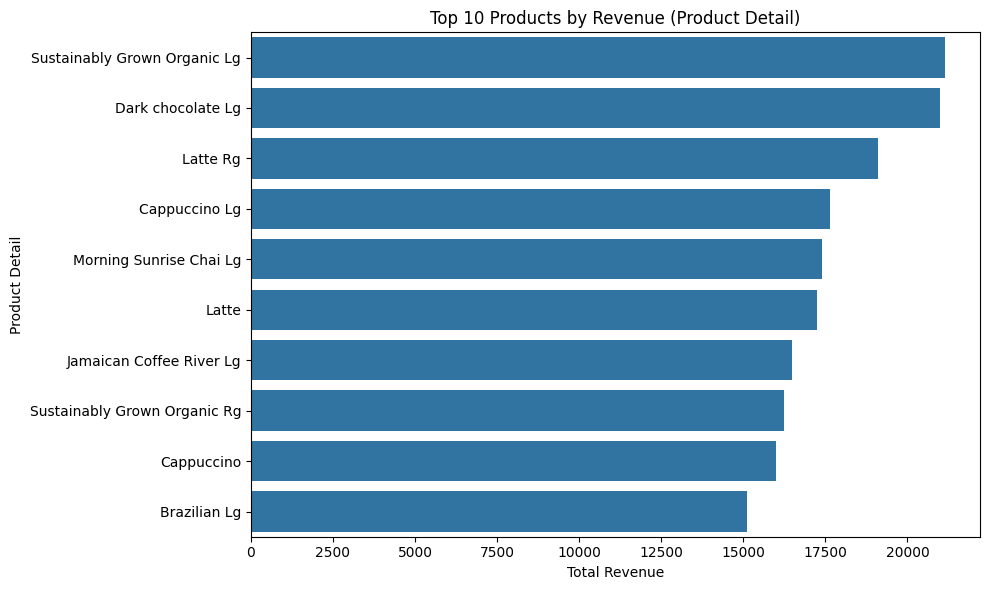

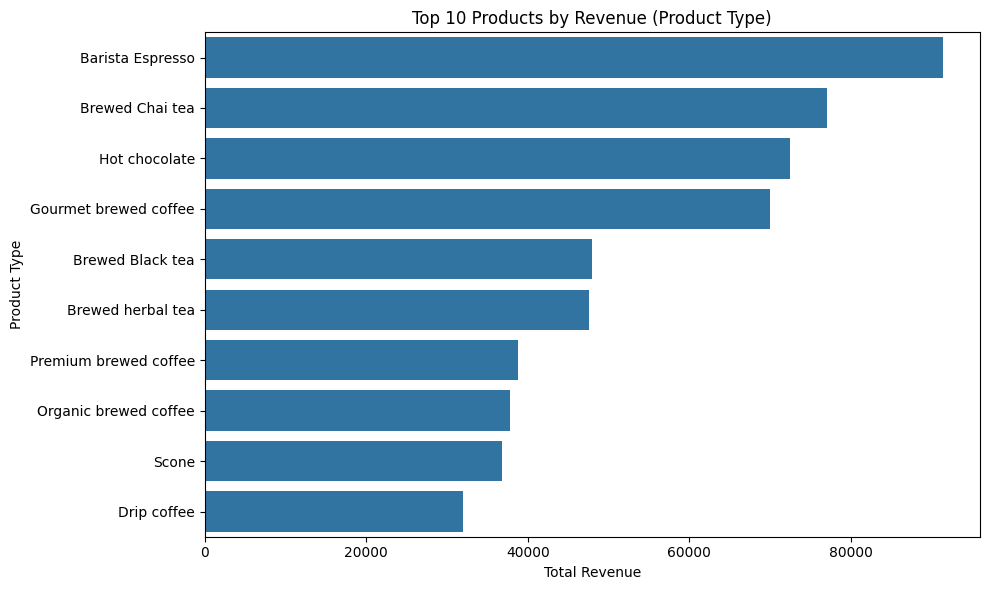

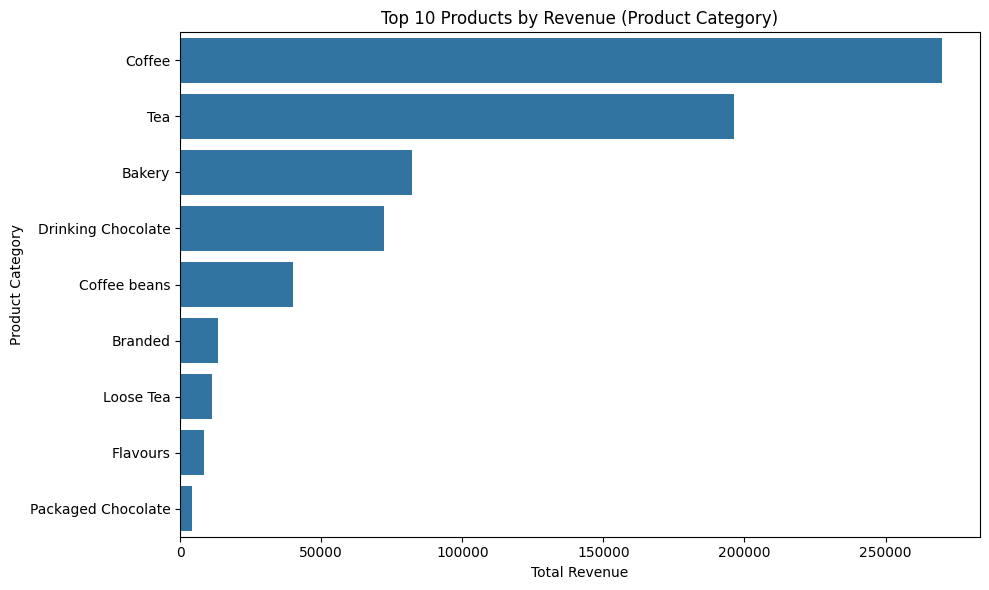

In [ ]:

import seaborn as sns

top_10_products = revenue_by_product_detail.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='revenue', y='product_detail', data=top_10_products)
plt.title('Top 10 Products by Revenue (Product Detail)')
plt.xlabel('Total Revenue')
plt.ylabel('Product Detail')
plt.tight_layout()
plt.show()


top_10_product_types = revenue_by_product_type.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='revenue', y='product_type', data=top_10_product_types)
plt.title('Top 10 Products by Revenue (Product Type)')
plt.xlabel('Total Revenue')
plt.ylabel('Product Type')
plt.tight_layout()
plt.show()

top_10_product_categories = revenue_by_product_category.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='revenue', y='product_category', data=top_10_product_categories)
plt.title('Top 10 Products by Revenue (Product Category)')
plt.xlabel('Total Revenue')
plt.ylabel('Product Category')
plt.tight_layout()
plt.show()


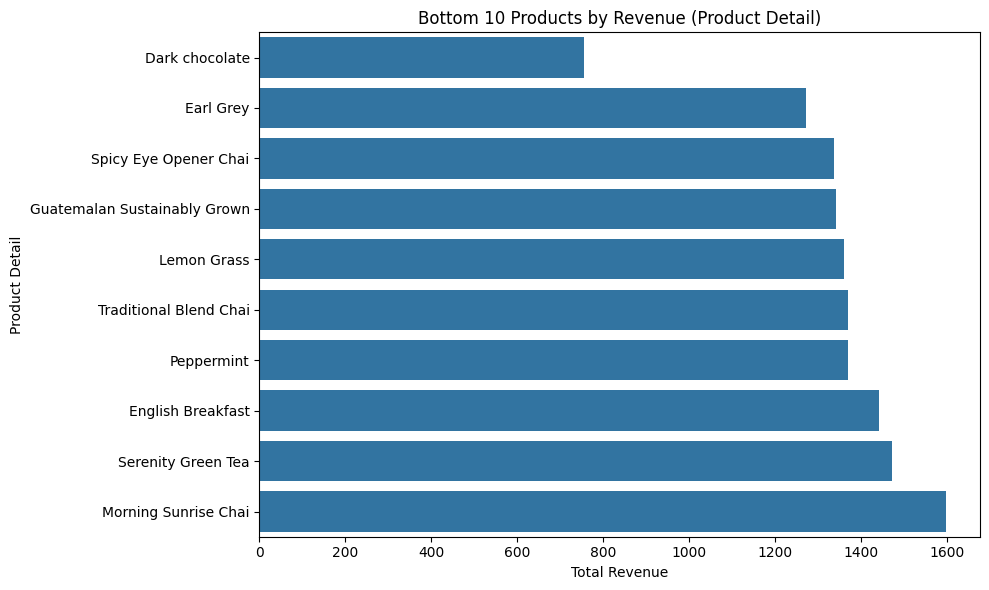

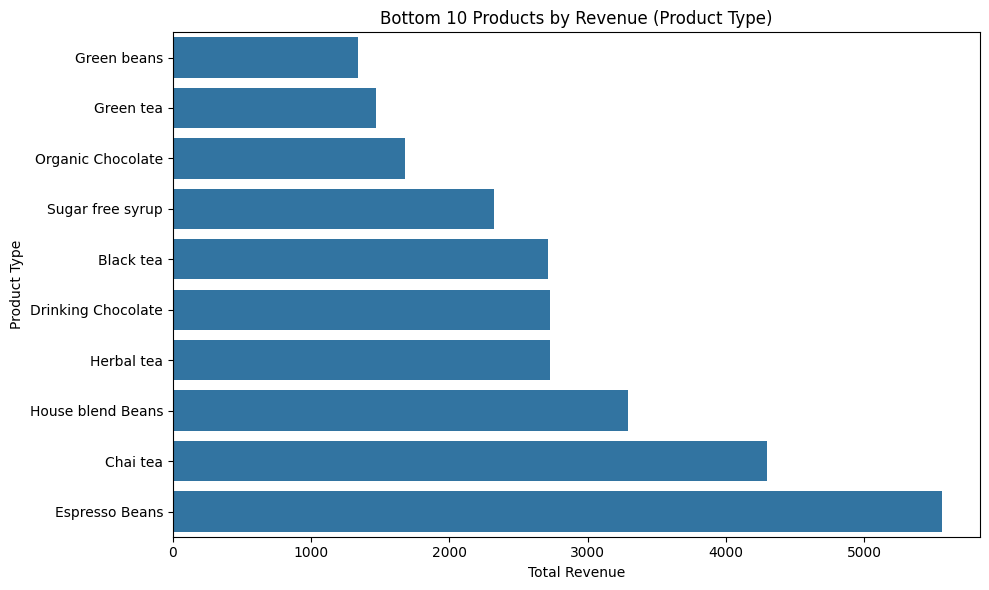

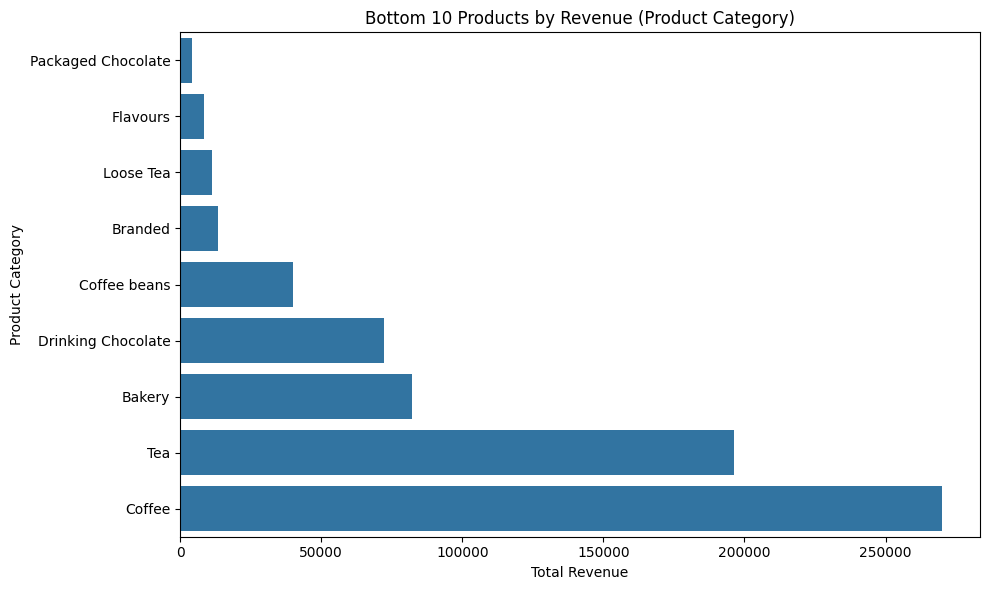

In [ ]:

bottom_10_products = revenue_by_product_detail_b.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='revenue', y='product_detail', data=bottom_10_products)
plt.title('Bottom 10 Products by Revenue (Product Detail)')
plt.xlabel('Total Revenue')
plt.ylabel('Product Detail')
plt.tight_layout()
plt.show()



bottom_10_product_types = revenue_by_product_type_b.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='revenue', y='product_type', data=bottom_10_product_types)
plt.title('Bottom 10 Products by Revenue (Product Type)')
plt.xlabel('Total Revenue')
plt.ylabel('Product Type')
plt.tight_layout()
plt.show()


bottom_10_product_categories = revenue_by_product_category_b.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='revenue', y='product_category', data=bottom_10_product_categories)
plt.title('Bottom 10 Products by Revenue (Product Category)')
plt.xlabel('Total Revenue')
plt.ylabel('Product Category')
plt.tight_layout()
plt.show()


In [ ]:


# Product efficiency (Revenue per transaction)
efficiency = data.groupby('product_detail').agg({
    'revenue': 'sum',
    'transaction_qty': 'sum'
}).reset_index()

efficiency['revenue_per_unit'] = (
    efficiency['revenue'] / efficiency['transaction_qty'])

In [ ]:
pareto = revenue_by_product_detail.copy()
pareto['cumulative_revenue'] = pareto['revenue'].cumsum()
pareto['cumulative_percentage'] = (
    pareto['cumulative_revenue'] / pareto['revenue'].sum() * 100
)


In [ ]:
data.to_csv('cleaned_afficionado_dataset.csv', index=False)